##TP CNN

In [10]:
#import
import os
from keras import backend as K
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv1D,Conv3D,Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt 
from tensorflow.keras.layers import Dropout

Dans la partie ci-dessus on a importé des bibliothèques nécessaires pour notre cas ,voire: tensorflow et keras.

In [2]:
os.chdir("./v_data")
img_width, img_height=224,224
train_data_dir='train'
validation_data_dir='test'
nb_train_samples=400
nb_validation_samples=100
epochs=15
batch_size=16
num_filters=8
filtre_size=3
if K.image_data_format() == 'channels_first':
    input_shape=(3,img_width,img_height)
else:
    input_shape=(img_width,img_height,3)
# print("on est sur:",os.getcwd())
# print(img_width , nb_train_samples, nb_train_smaples )

Dans cette partie on a dirigé notre programme vers le répertoire contenant notre data "v_data" puis on a defini le train_data_dir et le validation_data_dir (test_set) aussi les éléments nécessaires pour l'entrainement de notre CNN, comme nombre des itérations et du batch, la taille et le nombre filtres qui vont être appliques.
Puis on a ajouté une condition pour la forme de l'input de l'image.

In [3]:
train_datagen= ImageDataGenerator(rescale=1./255,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)
train_generator=train_datagen.flow_from_directory(train_data_dir,
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,
                                                  class_mode='categorical')
validation_generator=test_datagen.flow_from_directory(
                        validation_data_dir,
                        target_size=(img_width,img_height),
                        batch_size=batch_size,
                        class_mode='categorical')


train_datagen1=ImageDataGenerator(rescale = 1. / 255)
test_datagen1=ImageDataGenerator(rescale=1./255)
train_generator1=train_datagen.flow_from_directory(train_data_dir,
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,class_mode='categorical')
validation_generator1=test_datagen.flow_from_directory(
                        validation_data_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size, class_mode='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


Dans cette partie on a fait le scaling de notre train_set,et on a fait un shear_range de 20% pour déformer un coin de l'image afin de simuler les angles de vue différente.
On a applique aussi une zoom_range de 20% aussi pour rendre le modèle robuste aux différentes tailles des objets.
et horizontal_flip pour donner à notre modèle un vue droite et gauche ,c'est utile pour les symetries naturels comme de paysage, des visages mais pas utile au cas où on a des textes ou des chiffres, dans notre cas de plane/car c'est utile.
On scale aussi le test_set.
puis on a applique un chargement des images de train et de test.
Puis d'autres data-set train test (train_datagen1, validation_generator1), mais cette fois-ci sauf le scaling pas d'autres attributs pour voir comment ça va influencer en performance.

In [4]:
model=keras.Sequential()
model.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))
print(model.summary())

model1=keras.Sequential()
model1.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model1.add(Activation('relu'))
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Flatten())
model1.add(Dense(24))
model1.add(Dense(2))
model1.add(Activation('sigmoid'))
print(model1.summary())

C:\Users\Dell Latitude 7430\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


Ici on a créé deux modèles de même architectures CNN pour chacun. Un a entrainer par data_generator1 et l'autre par data_generator

In [5]:
model.compile(loss='binary_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
history=model.fit(train_generator,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator,
                    validation_steps=nb_validation_samples//batch_size)
model1.compile(loss='binary_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])
history1=model1.fit(train_generator1,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator1,
                    validation_steps=nb_validation_samples//batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 617ms/step - accuracy: 0.6275 - loss: 7.3600 - val_accuracy: 0.8438 - val_loss: 0.7803
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 582ms/step - accuracy: 0.6700 - loss: 1.6210 - val_accuracy: 0.8438 - val_loss: 0.4276
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 599ms/step - accuracy: 0.7775 - loss: 0.6668 - val_accuracy: 0.8854 - val_loss: 0.2443
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 595ms/step - accuracy: 0.7825 - loss: 0.5307 - val_accuracy: 0.7604 - val_loss: 0.5313
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 594ms/step - accuracy: 0.7975 - loss: 0.4861 - val_accuracy: 0.8750 - val_loss: 0.4823
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 584ms/step - accuracy: 0.8025 - loss: 0.5076 - val_accuracy: 0.8333 - val_loss: 0.4088
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 597ms/step - accuracy: 0.8450 - loss: 0.4140 - val_accuracy: 0.8438 - val_loss: 0.4807
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 587ms/step - accuracy: 0.8875 - loss: 0.3627 - val_accu

Ici on compile en preanant rmsprop comme optimizer et pour metrics accuracy et la fonction loss binary_crossentropy puisqu'on a ici une classification binaire. Puis on entraine nos modèles, et on affecte leur returns a la history et history1 afin de pouvoir les plotter.

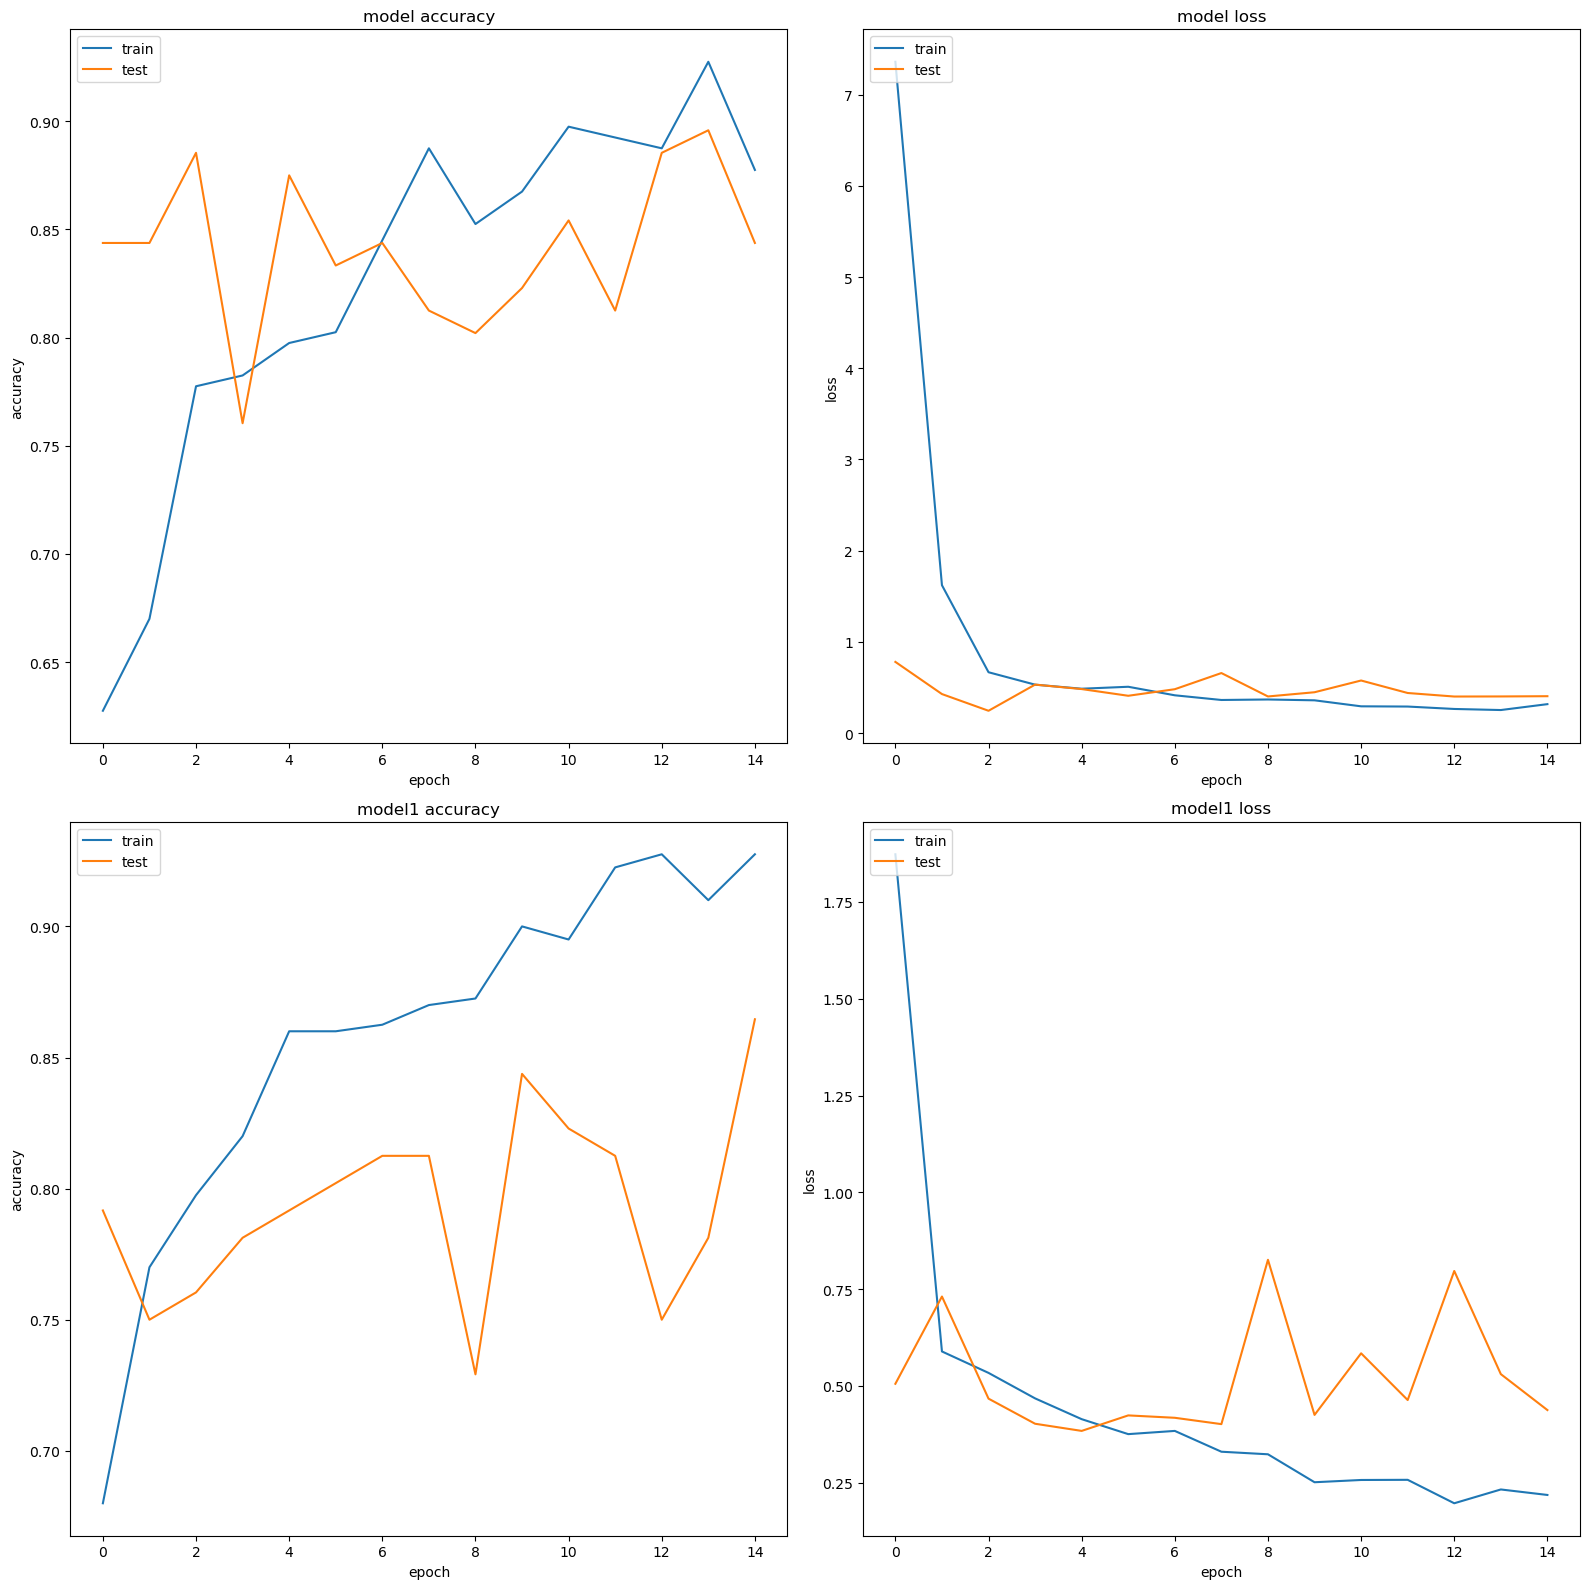

In [6]:
figure,ax=plt.subplots(2,2,figsize=(16,16))
ax[0,0].plot(history.history['accuracy'])
ax[0,0].plot(history.history['val_accuracy'])
ax[0,0].set_title('model accuracy')
ax[0,0].set_ylabel('accuracy')
ax[0,0].set_xlabel('epoch')
ax[0,0].legend(['train','test'],loc='upper left')

ax[0,1].plot(history.history['loss'])
ax[0,1].plot(history.history['val_loss'])
ax[0,1].set_title('model loss')
ax[0,1].set_ylabel('loss')
ax[0,1].set_xlabel('epoch')
ax[0,1].legend(['train','test'],loc='upper left')

ax[1,0].plot(history1.history['accuracy'])
ax[1,0].plot(history1.history['val_accuracy'])
ax[1,0].set_title('model1 accuracy')
ax[1,0].set_ylabel('accuracy')
ax[1,0].set_xlabel('epoch')
ax[1,0].legend(['train','test'],loc='upper left')

ax[1,1].plot(history1.history['loss'])
ax[1,1].plot(history1.history['val_loss'])
ax[1,1].set_title('model1 loss')
ax[1,1].set_ylabel('loss')
ax[1,1].set_xlabel('epoch')
ax[1,1].legend(['train','test'],loc='upper left')
plt.tight_layout()
plt.show()

Ici pour chaque modèle on a plotte deux 4 courbes pour loss et accuracy dans les deux cas de train et de test.
On voit les courbes d'accuracy pour model sont très proches et je vois loss aussi qui a chuté rapidement au début pour stagner dans un niveau.
Pour le deuxième modèle entraine par le train set qui est juste scales sans déformation et sans inverser, loss de test est un peu eleve par rapport a celle de train de même accuracy faible par rapport a celle de train --on peut déduire que notre modèle n'a pas bien généralise les résultats.
Donc notre modèle nécessite augmentation de donnes soit par shear_range/zoom_range ainsi de suite pour augmenter notre data_set d'entrainement pour plus de généralisation.

Maintenant dans cette section on va changer l'architecture CNN ,on va travailler avec une autre.et on va répéter les mêmes étapes qu'on a fait avec les autres modèles au premier.

In [14]:
model2=keras.Sequential()
model2.add(Conv2D(num_filters,(3,3),input_shape=input_shape))
model2.add(Activation('relu'))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Flatten())
model2.add(Dense(128))
model2.add(Dense(128))
model2.add(Dropout(0.2,seed=3))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dense(64))
model2.add(Dropout(0.3,seed=2))
model2.add(Dense(24))
model2.add(Dense(2))
model2.add(Activation('sigmoid'))
print(model1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,731,862 (18.05 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,365,932 (9.03 MB)

None


In [15]:
model2.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=['accuracy'])

In [16]:
history2=model2.fit(train_generator1,
                    steps_per_epoch=nb_train_samples//batch_size,
                    epochs=epochs,validation_data=validation_generator1,
                    validation_steps=nb_validation_samples//batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 665ms/step - accuracy: 0.5200 - loss: 65.1677 - val_accuracy: 0.7500 - val_loss: 0.8174
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 635ms/step - accuracy: 0.5475 - loss: 10.1365 - val_accuracy: 0.6042 - val_loss: 2.4179
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 627ms/step - accuracy: 0.6125 - loss: 2.6722 - val_accuracy: 0.7292 - val_loss: 0.5478
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 627ms/step - accuracy: 0.6900 - loss: 0.8139 - val_accuracy: 0.6979 - val_loss: 0.4815
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 683ms/step - accuracy: 0.7100 - loss: 0.6830 - val_accuracy: 0.6562 - val_loss: 1.1416
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 678ms/step - accuracy: 0.7400 - loss: 0.6198 - val_accuracy: 0.8333 - val_loss: 0.4428
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 625ms/step - accuracy: 0.8425 - loss: 0.4559 - val_accuracy: 0.8229 - val_loss: 0.4187
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 626ms/step - accuracy: 0.8550 - loss: 0.4041 - val_ac

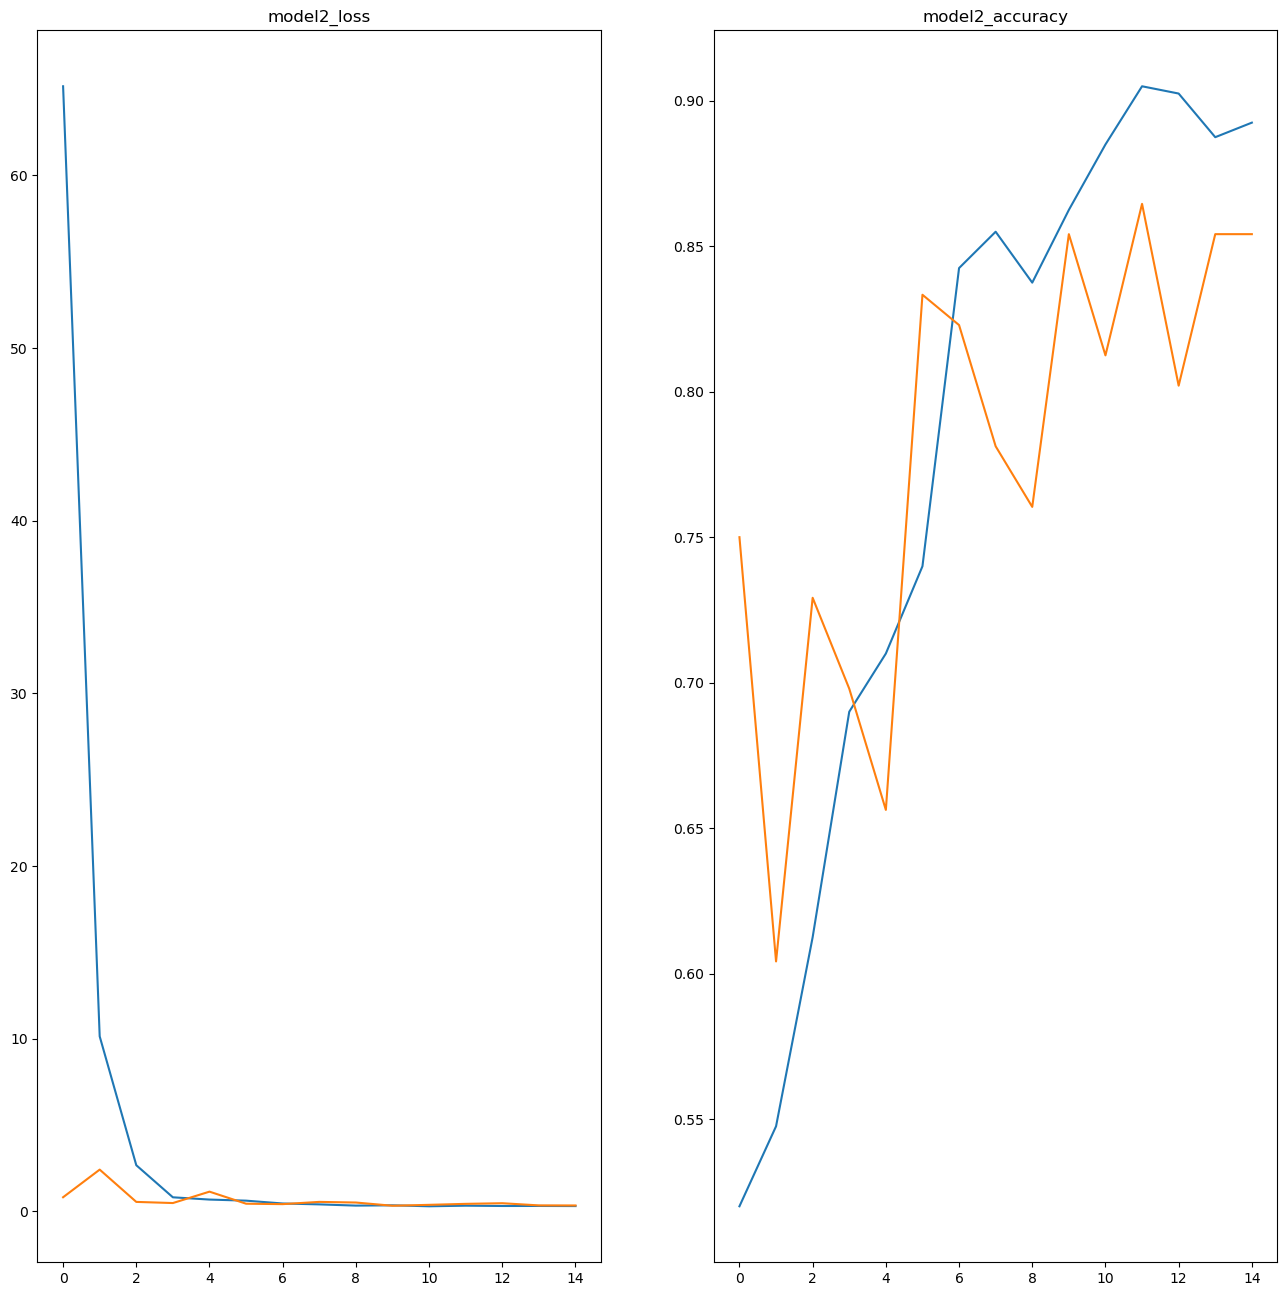

In [17]:
figure,ax=plt.subplots(1,2,figsize=(16,16))
ax[0].plot(history2.history['loss'])
ax[0].plot(history2.history['val_loss'])
ax[0].set_title("model2_loss")
ax[1].plot(history2.history['accuracy'])
ax[1].plot(history2.history['val_accuracy'])
ax[1].set_title("model2_accuracy")
plt.show()
             

###4 -Observation: 
On observe ici que loss dans le train a été très grande au début puis il a chuté pour stagner à cote de 0, avec une loss dans le test pas très grande puis il stagne au même niveau que dans le train.
Et pour l'accuracy on a dans le train un elevation pour qu'il joue autour de 0.90 pour l’accuracy de test varie entre 0.60 et 0.85 qui n’est pas trop mauvais.
-on peut dire qu'il y a un peu de overfitting qui doit être régularise mais en général cette architecture base dans model2 généralise correctement.

###5: 
On doit transformer le trainset par tf.image.rgb_to_grayscale et on doit changer aussi le input pour que le channel soit 1 pas 3.ou bien on va les charger avec fonctionnalité color_made='grayscale'.